# Spark Session Initialization & Data Loading

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("Instacart") \
    .config("spark.driver.memory", "6g") \
    .config("spark.driver.maxResultSize", "4g") \
    .getOrCreate()

print("Spark started")

df = spark.read.parquet("instamart_dataset.parquet")

Spark started


# Dataset Overview

In [2]:
df.count(), len(df.columns)

(32434489, 15)

# Missing Value Analysis

The null values are expected in the column 'days_since_prior_order' because there are customers who are buying first time from the store.

We need to replace nulls values with 0 or 'first_time_order'.

In [ ]:
from pyspark.sql.functions import col, when, count

df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()

# Basic Feature Engineering

In [3]:
from pyspark.sql.functions import col, when

df = df.withColumn("order_dow", col("order_dow").cast("int"))
df = df.withColumn("order_hour_of_day", col("order_hour_of_day").cast("int"))

df = df.fillna({"days_since_prior_order": 0})

df = df.withColumn("day_name",
    when(col("order_dow") == 0, "Sunday")
    .when(col("order_dow") == 1, "Monday")
    .when(col("order_dow") == 2, "Tuesday")
    .when(col("order_dow") == 3, "Wednesday")
    .when(col("order_dow") == 4, "Thursday")
    .when(col("order_dow") == 5, "Friday")
    .when(col("order_dow") == 6, "Saturday")
)

# Product Popularity Feature Engineering

In [4]:
from pyspark.sql.functions import count
from pyspark.sql.window import Window
from pyspark.sql.functions import ntile

product_freq = df.groupBy("product_name").agg(count("*").alias("order_count"))

window_spec = Window.orderBy(product_freq["order_count"].desc())

product_bucket = product_freq.withColumn("product_popularity",ntile(3).over(window_spec))

# Aisle Popularity Feature Engineering

In [5]:
aisle_freq = df.groupBy("aisle").agg(count("*").alias("order_count"))

window_spec = Window.orderBy(aisle_freq["order_count"].desc())

aisle_bucket = aisle_freq.withColumn("aisle_popularity",ntile(3).over(window_spec))

# Customer Behavior Feature Engineering

In [6]:
from pyspark.sql.functions import avg, countDistinct

customer_df = df.groupBy("user_id").agg(countDistinct("order_id").alias("total_orders"),avg("days_since_prior_order").alias("avg_days_between_orders"))

# Customer Segmentation

In [7]:
from pyspark.sql.functions import when

customer_df = customer_df.withColumn(
    "customer_type",
    when(col("avg_days_between_orders") <= 7, "Frequent")
    .when(col("avg_days_between_orders") <= 15, "Regular")
    .otherwise("Occasional")
)

customer_df = customer_df.withColumn(
    "loyalty_flag",
    when(col("total_orders") >= 10, "High")
    .otherwise("Low")
)

# Product Reorder Behavior

In [8]:
from pyspark.sql.functions import avg

reorder_df = df.groupBy("product_name").agg(avg("reordered").alias("product_reorder_rate"))

# Basket Size Feature Engineering

In [9]:
basket_df = df.groupBy("order_id").agg(count("product_id").alias("basket_size"))

# First Product Importance

In [10]:
first_product_df = df.filter(col("add_to_cart_order") == 1).groupBy("product_name").agg(avg("reordered").alias("first_product_reorder_rate"))

# Feature Integration (Joining All Features)

In [11]:
# Product features
df = df.join(product_bucket.select("product_name", "product_popularity"),on="product_name", how="left")

# Aisle features
df = df.join(aisle_bucket.select("aisle", "aisle_popularity"),on="aisle",how="left")

# Customer features
df = df.join(customer_df,on="user_id",how="left")

# Reorder features
df = df.join(reorder_df,on="product_name",how="left")

# Basket features
df = df.join(basket_df,on="order_id",how="left")

# First product features
df = df.join(first_product_df,on="product_name",how="left")

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Global theme
sns.set(style="whitegrid")

# Custom color palette (gradient style)
palette = sns.color_palette("viridis", as_cmap=False)

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14

# BUSINESS QUESTIONS 

# 1. Department Performance Analysis

+---------------+------------+
|     department|total_orders|
+---------------+------------+
|        produce|     9479291|
|     dairy eggs|     5414016|
|         snacks|     2887550|
|      beverages|     2690129|
|         frozen|     2236432|
|         pantry|     1875577|
|         bakery|     1176787|
|   canned goods|     1068058|
|           deli|     1051249|
|dry goods pasta|      866627|
+---------------+------------+
only showing top 10 rows


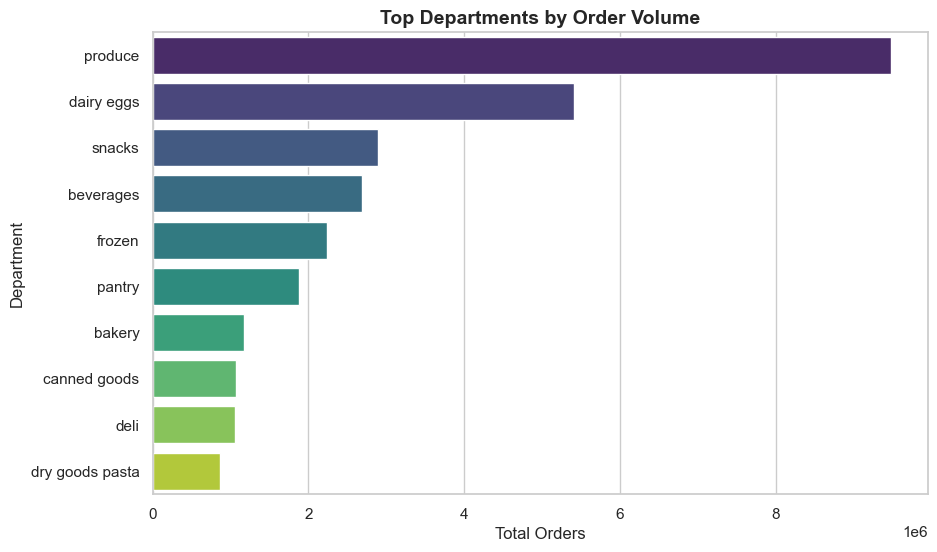

In [39]:
from pyspark.sql.functions import count

df.groupBy("department").agg(count("*").alias("total_orders")).orderBy("total_orders", ascending=False).show(10)

pdf_department = df.groupBy("department").count().orderBy("count", ascending=False).limit(10).toPandas()

sns.barplot(data=pdf_department, x="count", y="department", hue='department',palette="viridis",legend=False)
plt.title("Top Departments by Order Volume")
plt.xlabel("Total Orders")
plt.ylabel("Department")

plt.show()

## Insight:
- Produce dominates (~9.4M orders)
- Dairy & eggs also strong

## Decision:
- Increase inventory in produce
- Optimize supply chain for perishables
- Promote high-margin items in these departments

# 2. Aisle Performance Analysis

+--------------------+------------+
|               aisle|total_orders|
+--------------------+------------+
|        fresh fruits|     3642188|
|    fresh vegetables|     3418021|
|packaged vegetabl...|     1765313|
|              yogurt|     1452343|
|     packaged cheese|      979763|
|                milk|      891015|
|water seltzer spa...|      841533|
|      chips pretzels|      722470|
|     soy lactosefree|      638253|
|               bread|      584834|
+--------------------+------------+
only showing top 10 rows


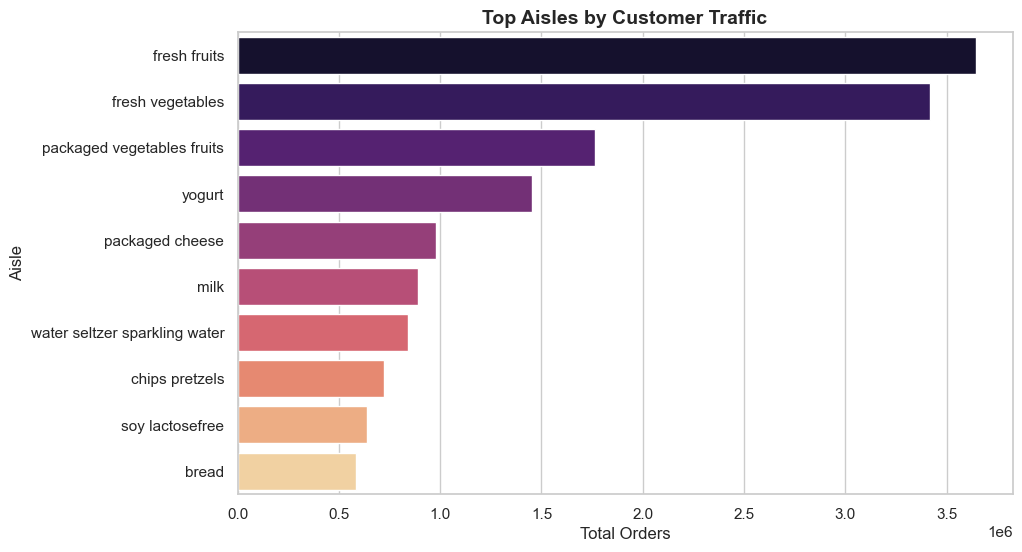

In [40]:
df.groupBy("aisle").agg(count("*").alias("total_orders")).orderBy("total_orders", ascending=False).show(10)

pdf_aisle = df.groupBy("aisle").count().orderBy("count", ascending=False).limit(10).toPandas()

sns.barplot(data=pdf_aisle, x="count", y="aisle", hue='aisle',palette="magma",legend=False)

plt.title("Top Aisles by Customer Traffic")
plt.xlabel("Total Orders")
plt.ylabel("Aisle")

plt.show()

## Insight:
- Fresh fruits & vegetables dominate
- Essentials drive traffic
## Decision:
- Place these aisles strategically (store layout)
- Bundle with complementary items (cross-sell)

# 3. Product Demand Analysis

+--------------------+---------------+
|        product_name|order_frequency|
+--------------------+---------------+
|              Banana|         472565|
|Bag of Organic Ba...|         379450|
|Organic Strawberries|         264683|
|Organic Baby Spinach|         241921|
|Organic Hass Avocado|         213584|
+--------------------+---------------+
only showing top 5 rows


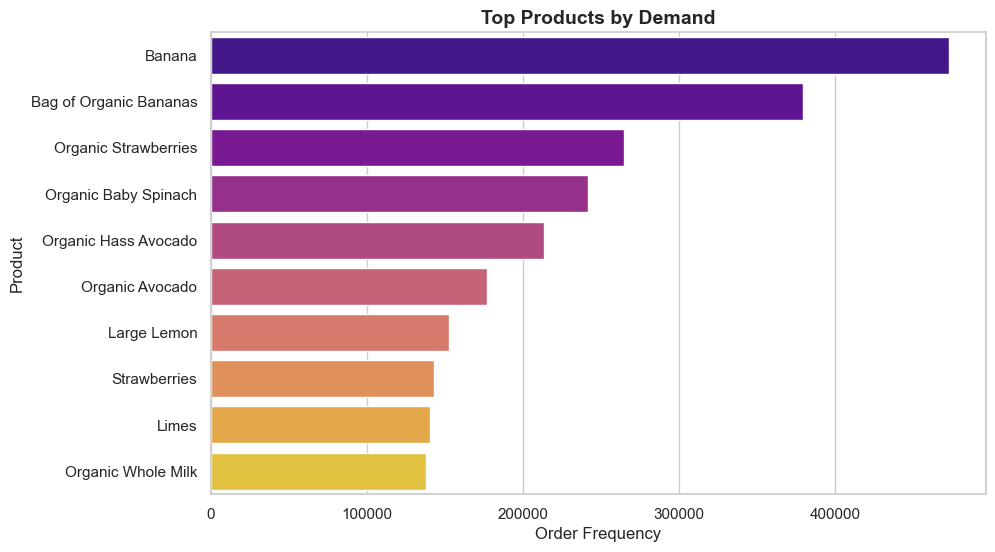

In [41]:
df.groupBy("product_name").agg(count("*").alias("order_frequency")).orderBy("order_frequency", ascending=False).show(5)

pdf_product = df.groupBy("product_name").count().orderBy("count", ascending=False).limit(10).toPandas()

sns.barplot(data=pdf_product, x="count", y="product_name",hue='product_name', palette="plasma",legend=False)

plt.title("Top Products by Demand")
plt.xlabel("Order Frequency")
plt.ylabel("Product")

plt.show()

## Insight:
- Bananas, organic fruits dominate
- Customers prefer healthy staples
## Decision:
- Prioritize stocking these
- Use them in recommendation systems
- Bundle: banana + milk + bread

# 4. Weekly Order Trends

+---------+------------+
| day_name|total_orders|
+---------+------------+
|   Sunday|     6209666|
|   Monday|     5665856|
| Saturday|     4500304|
|  Tuesday|     4217798|
|   Friday|     4209533|
|Wednesday|     3844117|
| Thursday|     3787215|
+---------+------------+



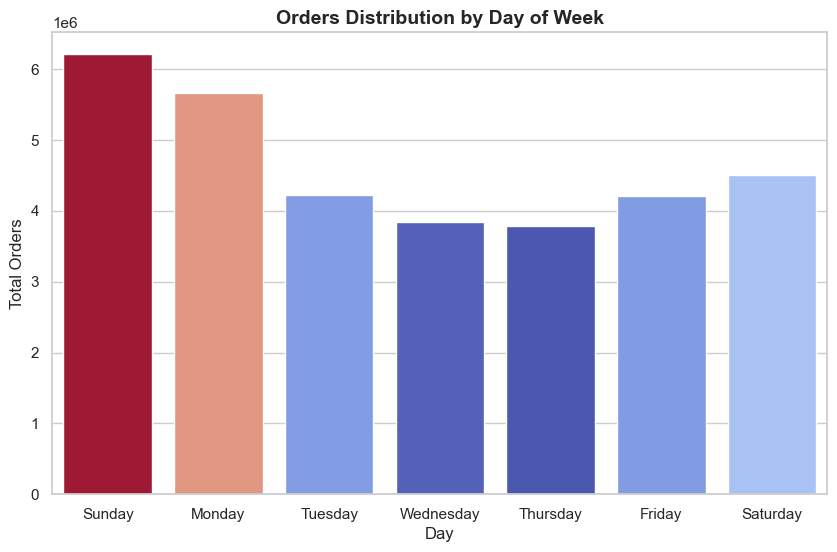

In [42]:
df.groupBy("day_name").agg(count("*").alias("total_orders")).orderBy("total_orders", ascending=False).show()

pdf_dayname = df.groupBy("day_name").count().toPandas()

order = ["Sunday","Monday","Tuesday","Wednesday","Thursday","Friday","Saturday"]

sns.barplot(data=pdf_dayname, x="day_name", y="count", order=order,hue='count', palette="coolwarm",legend=False)

plt.title("Orders Distribution by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Orders")

plt.show()

## Insight:
- Sunday highest orders
- Thursday lowest
## Decision:
- Run offers on low days (Thursday)
- Increase staffing on weekends

# 5. Hourly Order Trends

+-----------------+------------+
|order_hour_of_day|total_orders|
+-----------------+------------+
|               10|     2764426|
|               11|     2738582|
|               14|     2691548|
|               15|     2664533|
|               13|     2663292|
|               12|     2620847|
|               16|     2537458|
|                9|     2456713|
|               17|     2089465|
|                8|     1719973|
+-----------------+------------+
only showing top 10 rows


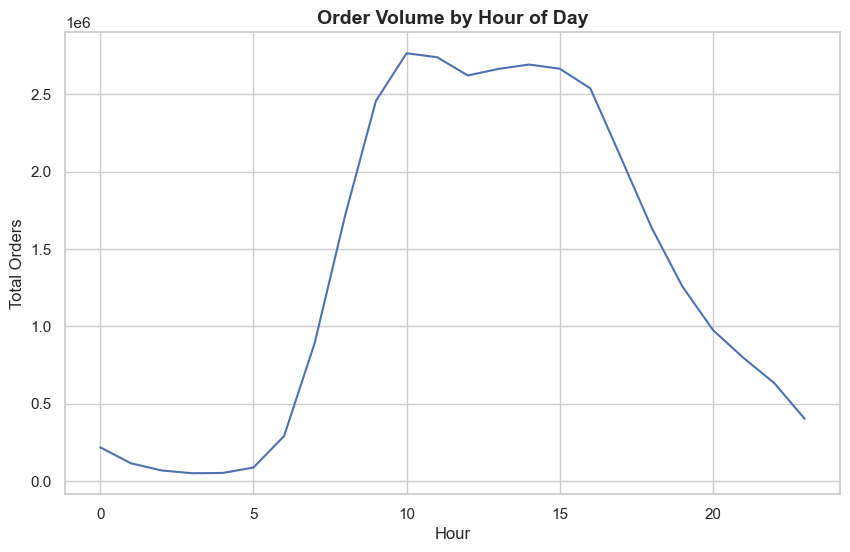

In [43]:
df.groupBy("order_hour_of_day").agg(count("*").alias("total_orders")).orderBy("total_orders", ascending=False).show(10)

pdf_hour = df.groupBy("order_hour_of_day").count().orderBy("order_hour_of_day").toPandas()

sns.lineplot(data=pdf_hour, x="order_hour_of_day", y="count")

plt.title("Order Volume by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Total Orders")

plt.show()

## Insight:
- Peak: 10 AM – 3 PM
## Decision:
- Optimize delivery slots
- Push ads during peak hours

# 6. Customer Segmentation Distribution

+-------------+---------+
|customer_type|num_users|
+-------------+---------+
|     Frequent|  9514346|
|      Regular| 16766828|
|   Occasional|  6153315|
+-------------+---------+



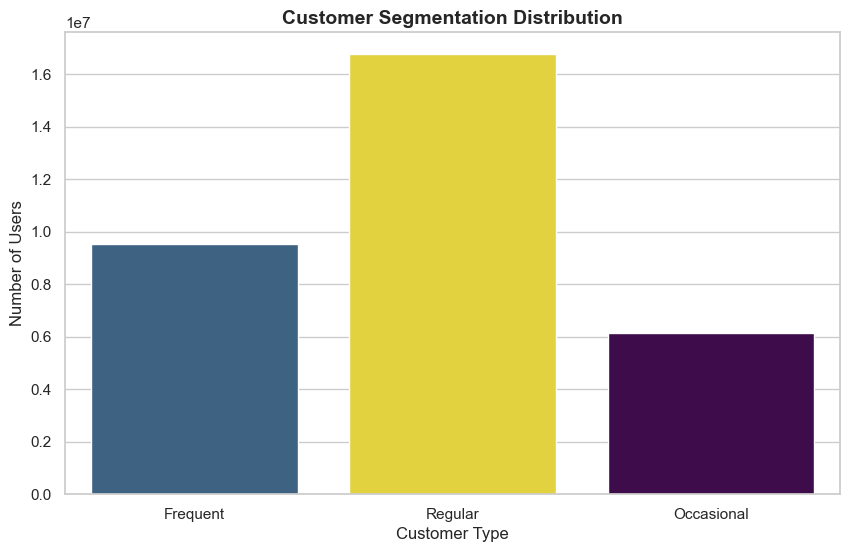

In [44]:
df.groupBy("customer_type").agg(count("*").alias("num_users")).show()

pdf_customertype = df.groupBy("customer_type").count().toPandas()

sns.barplot(data=pdf_customertype, x="customer_type", y="count",hue='count', palette="viridis",legend=False)

plt.title("Customer Segmentation Distribution")
plt.xlabel("Customer Type")
plt.ylabel("Number of Users")

plt.show()

## Insight:
- Majority = Regular customers
- Frequent customers are smaller but valuable
## Decision:
- Loyalty programs for frequent users
- Retarget occasional user

# 7. Customer Behavior vs Basket Size

+-------------+----------+
|customer_type|avg_basket|
+-------------+----------+
|     Frequent|     14.88|
|      Regular|     15.99|
|   Occasional|     16.19|
+-------------+----------+



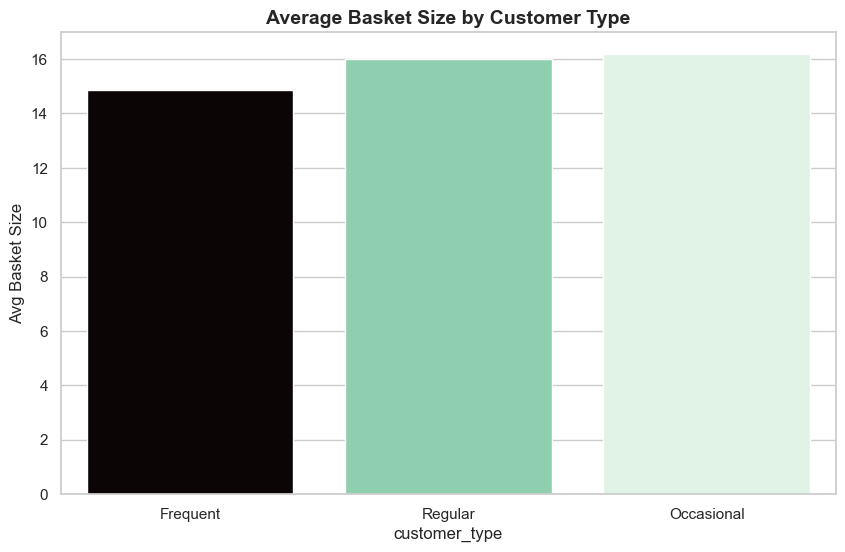

In [45]:
from pyspark.sql.functions import round

df.groupBy("customer_type").agg(round(avg("basket_size"),2).alias("avg_basket")).show()

pdf_customertype = df.groupBy("customer_type").agg(avg("basket_size").alias("avg_basket")).toPandas()

sns.barplot(data=pdf_customertype, x="customer_type", y="avg_basket",hue='avg_basket', palette="mako",legend=False)

plt.title("Average Basket Size by Customer Type")
plt.ylabel("Avg Basket Size")

plt.show()

## Insight:
- Occasional users → larger baskets
## Decision:
- Push bulk offers to occasional users
- Frequent users → smaller quick orders

# 8. Reorder Behavior by Department

In [19]:
df.groupBy("department").agg((round(avg("reordered"),2)*100).alias("reorder_rate")).orderBy("reorder_rate", ascending=False).show(10)

+------------+-----------------+
|  department|     reorder_rate|
+------------+-----------------+
|  dairy eggs|             67.0|
|   beverages|             65.0|
|     produce|             65.0|
|      bakery|             63.0|
|        deli|             61.0|
|        pets|             60.0|
|        bulk|57.99999999999999|
|      babies|57.99999999999999|
|meat seafood|56.99999999999999|
|     alcohol|56.99999999999999|
+------------+-----------------+
only showing top 10 rows


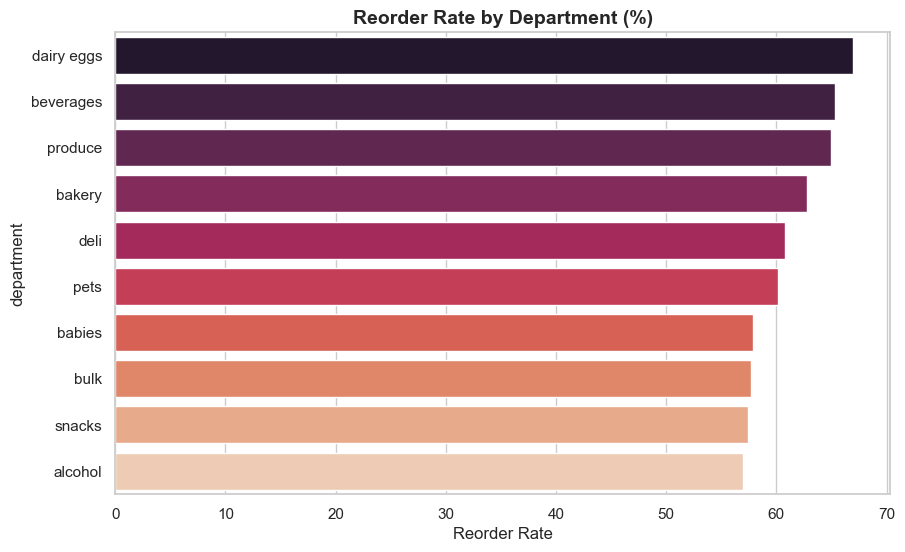

In [36]:
pdf_reordered = df.groupBy("department") \
    .agg((avg("reordered")*100).alias("reorder_rate")) \
    .orderBy("reorder_rate", ascending=False) \
    .limit(10) \
    .toPandas()

sns.barplot(data=pdf_reordered, x="reorder_rate", y="department",hue='department', palette="rocket",legend=False)

plt.title("Reorder Rate by Department (%)")
plt.xlabel("Reorder Rate")

plt.show()

## Insight:
- Dairy, beverages → highest reorder
## Decision:
- These are habit products
- Use subscription model / auto-reorder

# 9. Cart Position vs Reorder Behavior

+-----------------+-----------------+
|add_to_cart_order|     reorder_rate|
+-----------------+-----------------+
|                1|             68.0|
|                2|             68.0|
|                3|             66.0|
|                4|             64.0|
|                5|             62.0|
|                6|             60.0|
|                7|             59.0|
|                8|56.99999999999999|
|                9|56.00000000000001|
|               10|55.00000000000001|
+-----------------+-----------------+
only showing top 10 rows


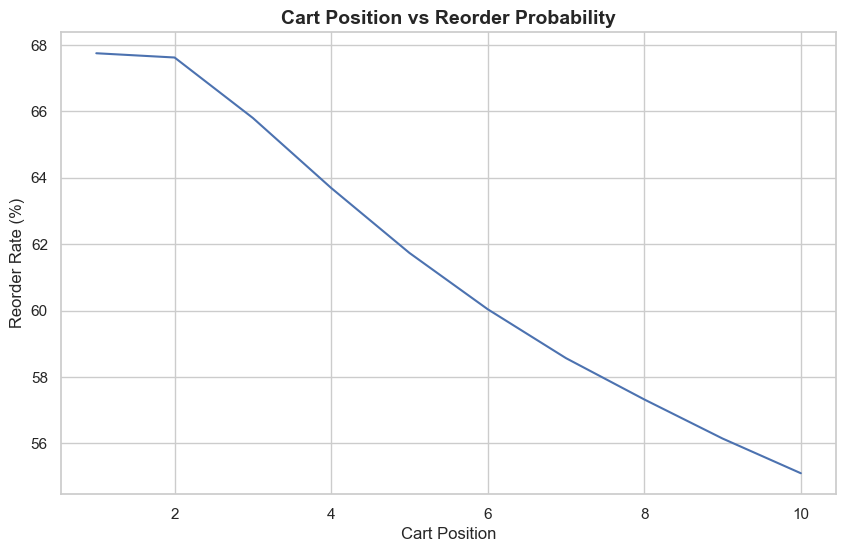

In [46]:
df.groupBy("add_to_cart_order").agg((round(avg("reordered"),2)*100).alias("reorder_rate")).orderBy("add_to_cart_order").show(10)

pdf_cartorder = df.groupBy("add_to_cart_order") .agg((avg("reordered")*100).alias("reorder_rate")).orderBy("add_to_cart_order").limit(10).toPandas()

sns.lineplot(data=pdf_cartorder, x="add_to_cart_order", y="reorder_rate")

plt.title("Cart Position vs Reorder Probability")
plt.xlabel("Cart Position")
plt.ylabel("Reorder Rate (%)")

plt.show()

## Insight:
- First items → highest reorder rate
## Decision:
- Show recommended products early
- Optimize UI/cart ranking

# 10. Popularity vs Reorder Behavior

+------------------+------------+
|product_popularity|reorder_rate|
+------------------+------------+
|                 1|        60.0|
|                 3|        26.0|
|                 2|        40.0|
+------------------+------------+



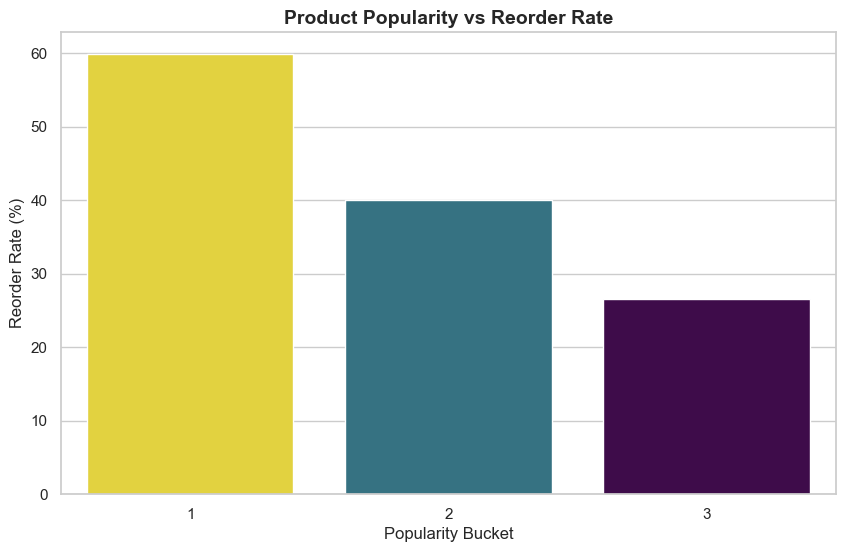

In [47]:
df.groupBy("product_popularity").agg((round(avg("reordered"),2)*100).alias("reorder_rate")).show()

pdf_product_popularity = df.groupBy("product_popularity").agg((avg("reordered")*100).alias("reorder_rate")).toPandas()

sns.barplot(data=pdf_product_popularity, x="product_popularity", y="reorder_rate",hue='reorder_rate', palette="viridis",legend=False)

plt.title("Product Popularity vs Reorder Rate")
plt.xlabel("Popularity Bucket")
plt.ylabel("Reorder Rate (%)")

plt.show()

## Insight:
- Most popular ≠ most reordered always
## Decision:
### Separate:
- High demand products
- High loyalty products